# ETF Pattern Matching with DTW — Interactive Demo

> **Project**: [etf-pattern-match-pybind11](https://github.com/redamancy231-create/etf-pattern-match-pybind11)  
> **License**: MIT  
> **Key numbers**: 34× DTW speedup · 53× pattern-match speedup · C++20 + pybind11  
> ⚠️ Speedup numbers are environment-dependent (measured on MSVC 19.51 / Windows 11)

---

## What This Notebook Covers

1. **The problem**: finding historical price patterns that resemble the current market
2. **The algorithm**: two-stage matching — cosine pre-filter → DTW refinement
3. **The features**: 15-dimensional morphological signature for each match
4. **The speedup**: Python vs C++ benchmark comparison
5. **Practical use**: scanning multiple time points for trading signals

---

## 本 Notebook 涵盖内容

1. **问题**: 寻找与当前市场形态相似的历史价格模式
2. **算法**: 两阶段形态匹配 — 余弦预筛选 → DTW 精排
3. **特征**: 每个匹配的 15 维形态签名
4. **加速**: Python vs C++ 性能对比
5. **实战**: 扫描多个时点生成交易信号

## 0. Setup & Imports

In [1]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from typing import Dict, List, Optional

# ── Path setup: find project root regardless of where notebook is launched ──
# Strategy: look for "src/core/dtw.py" relative to cwd or notebook dir
_NB_CWD = os.path.abspath("")
_PROJECT_ROOT = _NB_CWD
# If launched from notebooks/ dir, go up one level
if os.path.basename(_PROJECT_ROOT) == "notebooks":
    _PROJECT_ROOT = os.path.dirname(_PROJECT_ROOT)
# Verify we found it
_src_path = os.path.join(_PROJECT_ROOT, "src")
if not os.path.isdir(_src_path):
    # Fallback: try parent of cwd
    _PROJECT_ROOT = os.path.dirname(_NB_CWD)
    _src_path = os.path.join(_PROJECT_ROOT, "src")

sys.path.insert(0, _src_path)
print(f"Project root: {_PROJECT_ROOT}")

# Python reference implementation
from core.dtw import (
    standardize_returns,
    cosine_similarity,
    dtw_distance,
    dtw_distance_batch,
    generate_query_candidates,
)
from core.pattern_match import pattern_match_single, extract_morph_features
from IPython.display import Image, display

# Try loading C++ accelerated module
try:
    _cpp_path = os.path.join(_PROJECT_ROOT, "build", "Release")
    sys.path.insert(0, _cpp_path)
    import etf_core
    CPP_AVAILABLE = True
    print("✅ etf_core C++ module loaded — accelerated benchmarks available")
except ImportError:
    CPP_AVAILABLE = False
    print("⚠️  etf_core not built — Python-only mode")
    print("   Build: cmake -B build -DPython_EXECUTABLE=(Get-Command python).Source; cmake --build build --config Release")

# Plotting style
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 100,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print(f"\nNumPy version: {np.__version__}")
print(f"Ready.")

Project root: E:\workspace\projects\形态匹配ETF策略-pybind11
⚠️  etf_core not built — Python-only mode
   Build: cmake -B build -DPython_EXECUTABLE=(Get-Command python).Source; cmake --build build --config Release

NumPy version: 2.4.4
Ready.


## 1. Generate Synthetic ETF Price Data

We'll create a realistic price series with trends, mean-reversion, and volatility clustering — mimicking actual ETF behavior. This lets us test the algorithm without needing a market data API.

> **Data generation note**: Prices are generated from Gaussian simple returns with rolling volatility feedback (not log-normal returns or true GARCH). The dates use consecutive calendar days for simplicity — not actual trading-day calendars.

In [2]:
def generate_realistic_etf_prices(
    n_days: int = 800,
    start_price: float = 100.0,
    mu: float = 0.0003,          # daily drift (~8% annual)
    sigma: float = 0.012,         # daily volatility (~19% annual)
    regime_change_prob: float = 0.005,  # probability of regime switch per day
    seed: int = 42,
) -> np.ndarray:
    """
    Generate realistic ETF-like price series with:
    - Gaussian simple returns (not log-normal)
    - Rolling-window volatility feedback (simplified, not true GARCH)
    - Occasional trend reversals (regime changes)
    """
    rng = np.random.default_rng(seed)

    returns = np.zeros(n_days)
    current_mu = mu
    vol_window = 20

    for i in range(n_days):
        # Regime switch — occasional trend change
        if rng.random() < regime_change_prob:
            current_mu = rng.normal(0, 0.001)  # new drift

        # Volatility clustering: recent vol affects current vol
        if i >= vol_window:
            recent_vol = np.std(returns[i - vol_window:i])
            effective_sigma = 0.7 * sigma + 0.3 * recent_vol
        else:
            effective_sigma = sigma

        returns[i] = rng.normal(current_mu, effective_sigma)

    # Cumulative product to get prices
    prices = start_price * np.cumprod(1.0 + returns)
    return np.asarray(prices, dtype=np.float64)


# Generate data
prices = generate_realistic_etf_prices(n_days=800, seed=42)
dates = [datetime(2023, 1, 1) + timedelta(days=i) for i in range(len(prices))]

print(f"Generated {len(prices)} synthetic observations with calendar-day spacing")
print(f"  Start:  ${prices[0]:.2f}")
print(f"  End:    ${prices[-1]:.2f}")
print(f"  Return: {prices[-1]/prices[0] - 1:.1%}")
print(f"  Vol:    {np.std(np.diff(np.log(prices))):.2%} daily")

Generated 800 synthetic observations with calendar-day spacing
  Start:  $98.78
  End:    $73.31
  Return: -25.8%
  Vol:    1.19% daily


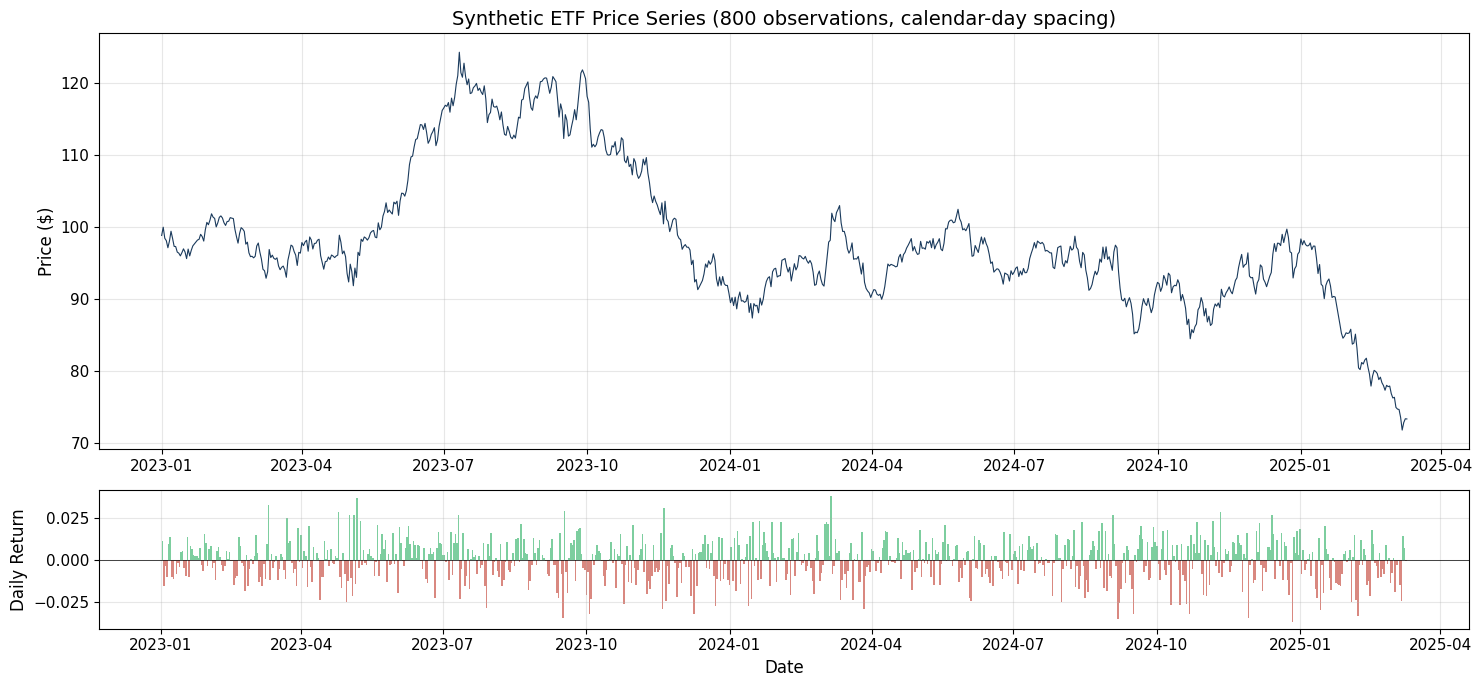

In [3]:
# Visualize the full price series
fig, axes = plt.subplots(2, 1, figsize=(15, 7), height_ratios=[3, 1])

# Price chart
axes[0].plot(dates, prices, linewidth=0.8, color="#1a3a5c")
axes[0].set_title("Synthetic ETF Price Series (800 observations, calendar-day spacing)")
axes[0].set_ylabel("Price ($)")
axes[0].grid(True, alpha=0.3)

# Daily returns
daily_rets = np.diff(np.log(prices))
axes[1].bar(dates[1:], daily_rets, width=1.0, color=["#c0392b" if r < 0 else "#27ae60" for r in daily_rets], alpha=0.6)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_ylabel("Daily Return")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_price_series.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.close()
display(Image('01_price_series.png'))

## 2. The Core Algorithm: Two-Stage Pattern Matching

### How It Works

```
    Query Window                Historical Search Space
    [ T-19 .. T ]               [ T-750 .. T-20 ]
         │                              │
         ▼                              ▼
  ┌──────────────┐           ┌──────────────────────┐
  │  Stage 1:    │──────────▶│  Cosine Pre-filter    │
  │  Standardize │           │  ~750 candidates O(L) │
  │  Returns     │           │  → Keep top-50        │
  └──────────────┘           └──────────┬───────────┘
                                        │
                                        ▼
                               ┌──────────────────────┐
                               │  Stage 2:            │
                               │  DTW Refinement      │
                               │  50 candidates O(L²) │
                               │  → Top-K matches     │
                               └──────────┬───────────┘
                                        │
                                        ▼
                               ┌──────────────────────┐
                               │  15-Dimensional      │
                               │  Feature Extraction  │
                               └──────────────────────┘
```

**Why two stages?** Computing DTW for all 750 candidates is O(750 × L²). Cosine similarity is O(L). By filtering to top-50 first, we get ~93% compute savings while retaining the best candidates.

**Look-ahead bias prevention**: All matching windows end at `search_end = T_idx - L_query`, ensuring we never use future data. The causal boundary is strictly enforced: `fut_end = hist_end + M_forward < T_idx`.

### 2.1 Step 1: Define Query Window & Standardize Returns

In [4]:
# Pick an analysis point
T_idx = 500  # day 500 of 800
L_query = 20  # 20-day query window

# Standardize: (log returns - mean) / std
query_prices = prices[T_idx - L_query + 1 : T_idx + 1]
query_rets = standardize_returns(query_prices)

print(f"Query window:  days [{T_idx - L_query + 1}, {T_idx}]")
print(f"Query prices:  {L_query} data points")
print(f"Query returns: {len(query_rets)} standardized log-returns")
print(f"  Mean: {np.mean(query_rets):.6f}  (≈ 0 after standardization)")
print(f"  Std:  {np.std(query_rets):.6f}   (≈ 1 after standardization)")

Query window:  days [481, 500]
Query prices:  20 data points
Query returns: 19 standardized log-returns
  Mean: 0.000000  (≈ 0 after standardization)
  Std:  1.000000   (≈ 1 after standardization)


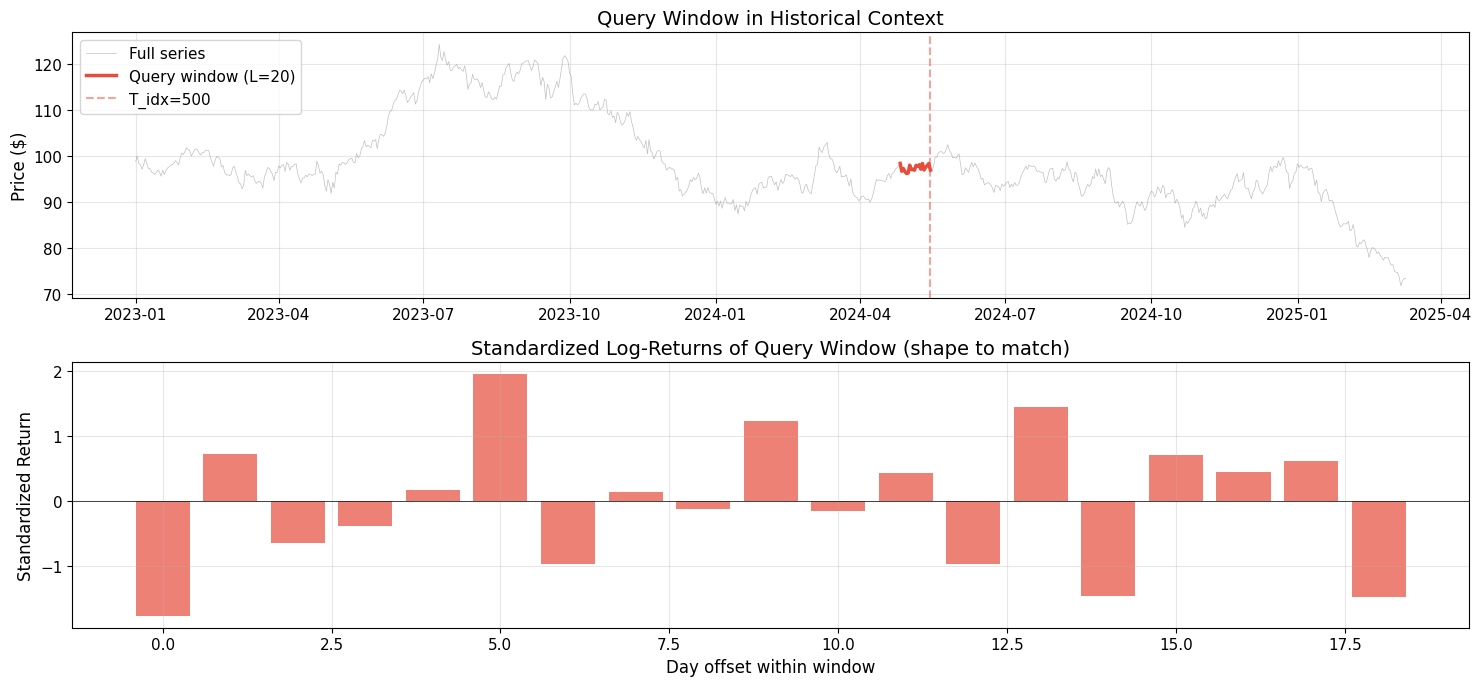

In [5]:
# Visualize: Query window in historical context
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

# Top: Full price series with query window highlighted
query_start = T_idx - L_query + 1
axes[0].plot(dates, prices, linewidth=0.5, color="gray", alpha=0.5, label="Full series")
axes[0].plot(dates[query_start:T_idx+1], prices[query_start:T_idx+1], 
             linewidth=2.5, color="#e74c3c", label=f"Query window (L={L_query})")
axes[0].axvline(x=dates[T_idx], color="#e74c3c", linestyle="--", alpha=0.5, label=f"T_idx={T_idx}")
axes[0].set_title("Query Window in Historical Context")
axes[0].set_ylabel("Price ($)")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Bottom: Standardized returns — this is what we match on
axes[1].bar(range(len(query_rets)), query_rets, color="#e74c3c", alpha=0.7)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_title("Standardized Log-Returns of Query Window (shape to match)")
axes[1].set_xlabel("Day offset within window")
axes[1].set_ylabel("Standardized Return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_query_window.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.close()
display(Image('02_query_window.png'))

### 2.2 Step 2: Cosine Pre-Filter — Scan All Historical Windows

In [6]:
# Generate candidate windows from history
q_prices, candidates_prices, candidate_ends = generate_query_candidates(
    prices, T_idx, L_query=L_query, T_back=750, match_step=1
)

# Standardize all candidate returns and compute cosine similarity + fast shape distances
query_r = standardize_returns(q_prices)
cos_sims = np.empty(len(candidates_prices))
fast_shape_dists = np.empty(len(candidates_prices))  # RMSD for all candidates

for i in range(len(candidates_prices)):
    cand_r = standardize_returns(candidates_prices[i])
    cos_sims[i] = cosine_similarity(cand_r, query_r)
    # Fast shape distance (RMSD) — used by real API for sigma calibration
    fast_shape_dists[i] = np.sqrt(np.mean((cand_r - query_r) ** 2))

# Keep only cos > 0 candidates + top-N by cosine
positive_mask = cos_sims > 0
cos_positive = cos_sims[positive_mask]
cos_prefilter_top = 50
top_n = min(cos_prefilter_top, len(cos_positive))
top_cos_idx = np.argsort(cos_positive)[::-1][:top_n]

print(f"Total candidates scanned: {len(candidates_prices)}")
print(f"Cosine > 0:              {np.sum(positive_mask)}")
print(f"Top-{top_n} by cosine retained for DTW refinement")
print(f"\nCosine similarity range: [{cos_sims.min():.3f}, {cos_sims.max():.3f}]")

Total candidates scanned: 462
Cosine > 0:              229
Top-50 by cosine retained for DTW refinement

Cosine similarity range: [-0.719, 0.654]


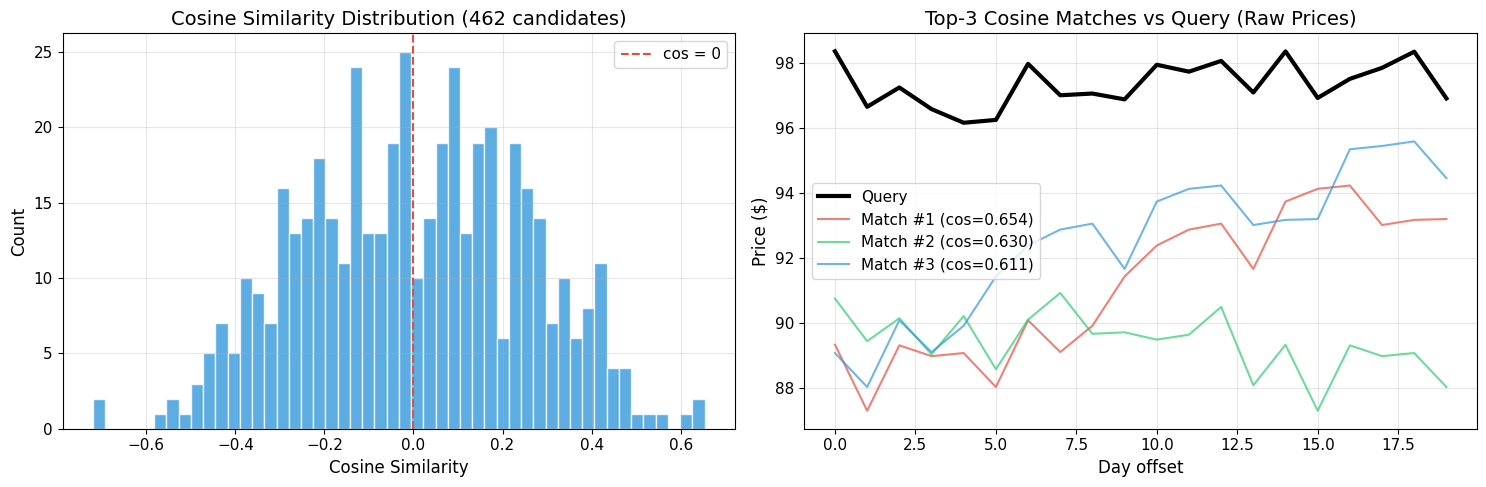

In [7]:
# Visualize cosine pre-filter results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Cosine similarity histogram
axes[0].hist(cos_sims, bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(x=0, color="#e74c3c", linestyle="--", linewidth=1.5, label="cos = 0")
axes[0].set_title(f"Cosine Similarity Distribution ({len(cos_sims)} candidates)")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Top-3 best cosine matches vs query (raw prices)
colors = ["#e74c3c", "#2ecc71", "#3498db"]
axes[1].plot(query_prices, linewidth=3, color="black", label="Query", zorder=10)
for rank, (ci, color) in enumerate(zip(top_cos_idx[:3], colors)):
    # Find original index in candidates_prices
    orig_idx = np.where(positive_mask)[0][ci]
    axes[1].plot(candidates_prices[orig_idx], linewidth=1.5, color=color, alpha=0.7,
                 label=f"Match #{rank+1} (cos={cos_positive[ci]:.3f})")
axes[1].set_title("Top-3 Cosine Matches vs Query (Raw Prices)")
axes[1].set_xlabel("Day offset")
axes[1].set_ylabel("Price ($)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_cosine_prefilter.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.close()
display(Image('03_cosine_prefilter.png'))

### 2.3 Step 3: DTW Refinement — Warp-Aware Matching

Cosine similarity measures 
**point-by-point alignment** — day 1 vs day 1, day 2 vs day 2.  
DTW allows **non-linear warping** — a 3-day rally in history can match a 2-day rally today.

This is critical for financial patterns: markets speed up and slow down, but the *shape* repeats.

In [8]:
# DTW compute on top cosine candidates
dtw_window = 5  # Sakoe-Chiba band
dtw_dists = []

for ci in top_cos_idx:
    orig_idx = np.where(positive_mask)[0][ci]
    cand_r = standardize_returns(candidates_prices[orig_idx])
    d = dtw_distance(cand_r, query_r, window=dtw_window)
    dtw_dists.append(d)

dtw_dists = np.array(dtw_dists)
cos_top = cos_positive[top_cos_idx]

# ── Scoring matches the real pattern_match_single implementation ──
# sigma_fast: calibrated from ALL candidates' fast_shape_dists (RMSD),
# scaled by 1/(2*sqrt(L-1)) to match DTW's normalization convention
sigma_fast = (
    np.std(fast_shape_dists) / (2.0 * np.sqrt(L_query - 1))
    if len(fast_shape_dists) > 1
    else 1.0
)
sigma_fast = max(sigma_fast, 1e-12)

# RBF kernel with sigma_fast → min-max normalize (global cos bounds) → 0.5*DTW + 0.5*cosine
sim_dtw = np.exp(-dtw_dists / sigma_fast)
norm_dtw = (sim_dtw - sim_dtw.min()) / (sim_dtw.max() - sim_dtw.min() + 1e-12)
norm_cos = (cos_top - cos_positive.min()) / (cos_positive.max() - cos_positive.min() + 1e-12)
combined = 0.5 * norm_dtw + 0.5 * norm_cos

print(f"DTW refinement on top-{top_n} candidates:")
print(f"  sigma_fast: {sigma_fast:.6f}  (calibrated from {len(fast_shape_dists)} candidates)")
print(f"  DTW distances:  [{dtw_dists.min():.4f}, {dtw_dists.max():.4f}]")
print(f"  Combined score: [{combined.min():.3f}, {combined.max():.3f}]")

DTW refinement on top-50 candidates:
  sigma_fast: 0.020809  (calibrated from 462 candidates)
  DTW distances:  [0.0777, 0.1107]
  Combined score: [0.251, 0.982]


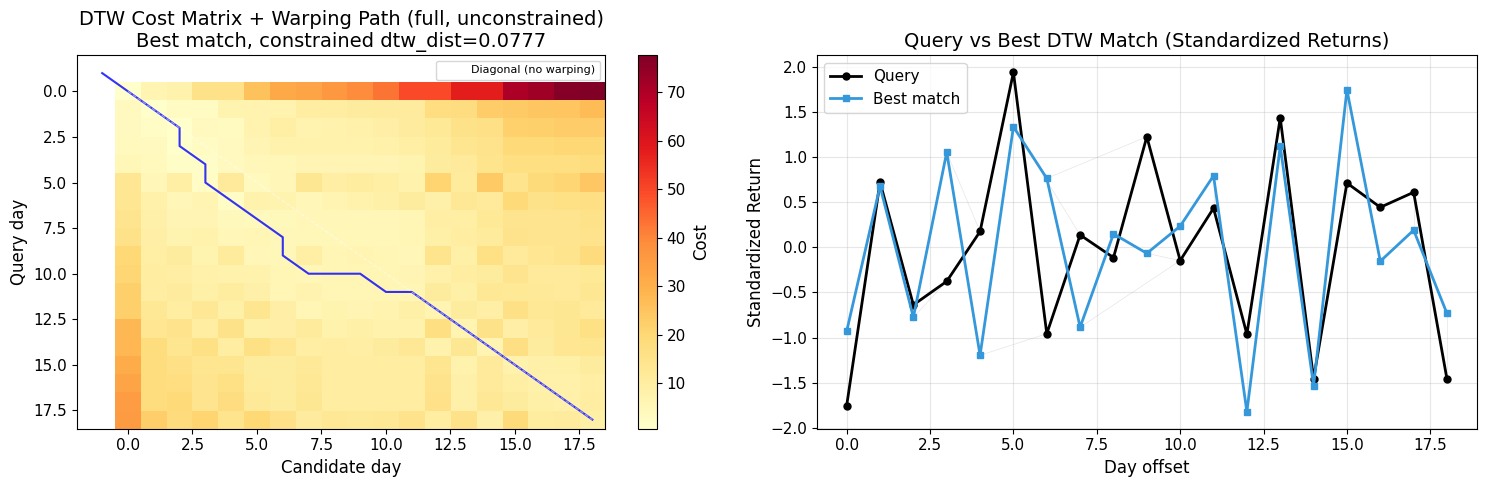

In [9]:
# ⚠️ Educational note: The DTW matrix below is computed WITHOUT the Sakoe-Chiba
# band constraint (window=∞) to show the full warping path for visualization.
# The actual distance value reported in the title uses the constrained DTW
# (window=5) — as does the real pattern_match_single API.
#
# Visualize DTW warping path for best match
best_idx = np.argmax(combined)
best_cand_idx = np.where(positive_mask)[0][top_cos_idx[best_idx]]
best_cand_r = standardize_returns(candidates_prices[best_cand_idx])

# Compute FULL DTW matrix for visualization (unconstrained — clearer warping picture)
n, m = len(query_r), len(best_cand_r)
dtw_mat = np.full((n + 1, m + 1), np.inf)
dtw_mat[0, 0] = 0.0
for i in range(1, n + 1):
    for j in range(1, m + 1):
        cost = (query_r[i-1] - best_cand_r[j-1]) ** 2
        dtw_mat[i, j] = cost + min(dtw_mat[i-1, j], dtw_mat[i, j-1], dtw_mat[i-1, j-1])

# Backtrack for warping path
path = [(n, m)]
i, j = n, m
while i > 0 or j > 0:
    if i == 0:
        j -= 1
    elif j == 0:
        i -= 1
    else:
        steps = [(i-1, j-1, dtw_mat[i-1, j-1]), (i-1, j, dtw_mat[i-1, j]), (i, j-1, dtw_mat[i, j-1])]
        best_step = min(steps, key=lambda x: x[2])
        i, j = best_step[0], best_step[1]
    path.append((i, j))
path = np.array(path)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: DTW matrix + warping path
im = axes[0].imshow(dtw_mat[1:, 1:], origin="upper", cmap="YlOrRd", aspect="auto")
axes[0].plot(path[:, 1] - 1, path[:, 0] - 1, color="blue", linewidth=1.5, alpha=0.8)
axes[0].plot([0, m-1], [0, n-1], color="white", linestyle="--", linewidth=0.8, alpha=0.5, label="Diagonal (no warping)")
axes[0].set_title(f"DTW Cost Matrix + Warping Path (full, unconstrained)\nBest match, constrained dtw_dist={dtw_dists[best_idx]:.4f}")
axes[0].set_xlabel("Candidate day")
axes[0].set_ylabel("Query day")
axes[0].legend(fontsize=8)
plt.colorbar(im, ax=axes[0], label="Cost")

# Right: Query vs Best Match returns (with warping connections)
x_q = np.arange(len(query_r))
x_c = np.arange(len(best_cand_r))
axes[1].plot(x_q, query_r, "o-", linewidth=2, markersize=5, color="black", label="Query")
axes[1].plot(x_c, best_cand_r, "s-", linewidth=2, markersize=5, color="#3498db", label="Best match")
# Draw a few warping connections
for step_idx in np.linspace(0, len(path)-1, 15, dtype=int):
    qi, ci = path[step_idx]
    if qi > 0 and ci > 0:
        axes[1].plot([ci-1, qi-1], [best_cand_r[ci-1], query_r[qi-1]],
                     color="gray", alpha=0.2, linewidth=0.5, zorder=0)
axes[1].set_title("Query vs Best DTW Match (Standardized Returns)")
axes[1].set_xlabel("Day offset")
axes[1].set_ylabel("Standardized Return")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_dtw_warping.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.close()
display(Image('04_dtw_warping.png'))

## 3. One-Call API: `pattern_match_single()`

All the steps above are packaged into a single call that returns the **15-dimensional morphological feature vector**.

In [10]:
# The full algorithm in ONE call
features = pattern_match_single(prices, T_idx=500)

if features:
    # Group features by category
    similarity_features = ["top1_sim", "top5_avg_sim", "sim_decay", "sim_variance", "match_distance_ratio"]
    future_ret_features = ["avg_future_ret", "weighted_future_ret", "median_future_ret",
                           "ret_sign_consistency", "best_match_ret", "max_dd_in_matches"]
    quality_features = ["match_time_span", "match_time_span_ratio", "match_cluster_ratio", "n_matches_above_thresh"]
    
    print("=" * 60)
    print("15-DIMENSIONAL MORPHOLOGICAL FEATURE VECTOR")
    print("=" * 60)
    
    print("\n📊 F1-F5: Similarity Features")
    print("-" * 40)
    for key in similarity_features:
        print(f"  {key:28s} = {features[key]:.6f}")
    
    print("\n📈 F6-F11: Forward Return Features")
    print("-" * 40)
    for key in future_ret_features:
        print(f"  {key:28s} = {features[key]:.6f}")
    
    print("\n🔍 F12-F15: Match Quality Features")
    print("-" * 40)
    for key in quality_features:
        print(f"  {key:28s} = {features[key]:.6f}")
else:
    print("❌ Insufficient data at T_idx=500")

15-DIMENSIONAL MORPHOLOGICAL FEATURE VECTOR

📊 F1-F5: Similarity Features
----------------------------------------
  top1_sim                     = 0.982057
  top5_avg_sim                 = 0.838216
  sim_decay                    = 0.143841
  sim_variance                 = 0.007585
  match_distance_ratio         = 0.146469

📈 F6-F11: Forward Return Features
----------------------------------------
  avg_future_ret               = 0.018050
  weighted_future_ret          = 0.019141
  median_future_ret            = 0.014485
  ret_sign_consistency         = 0.900000
  best_match_ret               = 0.049341
  max_dd_in_matches            = 0.006462

🔍 F12-F15: Match Quality Features
----------------------------------------
  match_time_span              = 429.000000
  match_time_span_ratio        = 0.572000
  match_cluster_ratio          = 0.300000
  n_matches_above_thresh       = 3.000000


### Feature Interpretation Guide

| # | Feature | Range | What It Tells You |
|:--|:--------|:------|:-------------------|
| **F1** | `top1_sim` | [0, 1] | Best match quality. >0.8 = strong pattern |
| **F2** | `top5_avg_sim` | [0, 1] | Average of top-5. Close to F1 = many good matches |
| **F3** | `sim_decay` | [0, 1] | F1 − F2. Large = one standout match dominates |
| **F4** | `sim_variance` | [0, ~0.25] | Score dispersion. High = uncertain match quality |
| **F5** | `match_distance_ratio` | [0, 1] | Relative score decay (F3 / F1). >0.5 = the top match is isolated from the rest |
| **F6** | `avg_future_ret` | (−1, +∞) | Simple average of forward returns after historical matches |
| **F7** | `weighted_future_ret` | (−1, +∞) | Score-weighted forward return (better matches weighted higher) |
| **F8** | `median_future_ret` | (−1, +∞) | Robust center of forward return distribution |
| **F9** | `ret_sign_consistency` | [0, 1] | Proportion of matches with positive forward returns. 0 = all bearish (perfectly consistent bearish), 1 = all bullish. Use `max(p, 1-p)` for directional consistency. |
| **F10** | `best_match_ret` | (−1, +∞) | Forward return after the single highest-scoring match |
| **F11** | `max_dd_in_matches` | [0, +∞) | Worst loss among match forward returns (= `max(0, −min(rets))`). Note: this is the worst single-period forward loss, NOT a path-based maximum drawdown. |
| **F12** | `match_time_span` | [0, T_back−L] | Index span between oldest and newest match (bar count, not calendar days) |
| **F13** | `match_time_span_ratio` | [0, ~0.97] | F12 / T_back. High = matches drawn from across the full lookback |
| **F14** | `match_cluster_ratio` | [1/K_actual, 1] | Max fraction of matches within a 60-bar window. >0.5 = matches are concentrated in one period (potential overfitting) |
| **F15** | `n_matches_above_thresh` | [0, K_actual] | Count of matches with combined score > 0.8. <2 = weak pattern confidence |

> **Range notes**: F6–F10 use simple returns `p[t+n]/p[t] − 1`, whose theoretical range is (−1, +∞) for positive prices. K_actual is the effective K after NaN-filtering and may be less than configured K.

### 3.1 Visualize Feature Evolution Over Time

Scan multiple time points to see how the 15-dimensional signature changes as the market evolves.

In [11]:
# Scan multiple time points
scan_points = list(range(200, 750, 10))
all_features: List[Optional[Dict[str, float]]] = []

for T in scan_points:
    all_features.append(pattern_match_single(prices, T))

# Extract key features over time
valid_indices = [i for i, f in enumerate(all_features) if f is not None]
valid_dates = [dates[scan_points[i]] for i in valid_indices]

top1_sim_series = [all_features[i]["top1_sim"] for i in valid_indices]
avg_future_ret_series = [all_features[i]["avg_future_ret"] for i in valid_indices]
ret_consistency_series = [all_features[i]["ret_sign_consistency"] for i in valid_indices]
cluster_ratio_series = [all_features[i]["match_cluster_ratio"] for i in valid_indices]

print(f"Scanned {len(scan_points)} points, {len(valid_indices)} valid ({len(scan_points) - len(valid_indices)} insufficient data)")

Scanned 55 points, 55 valid (0 insufficient data)


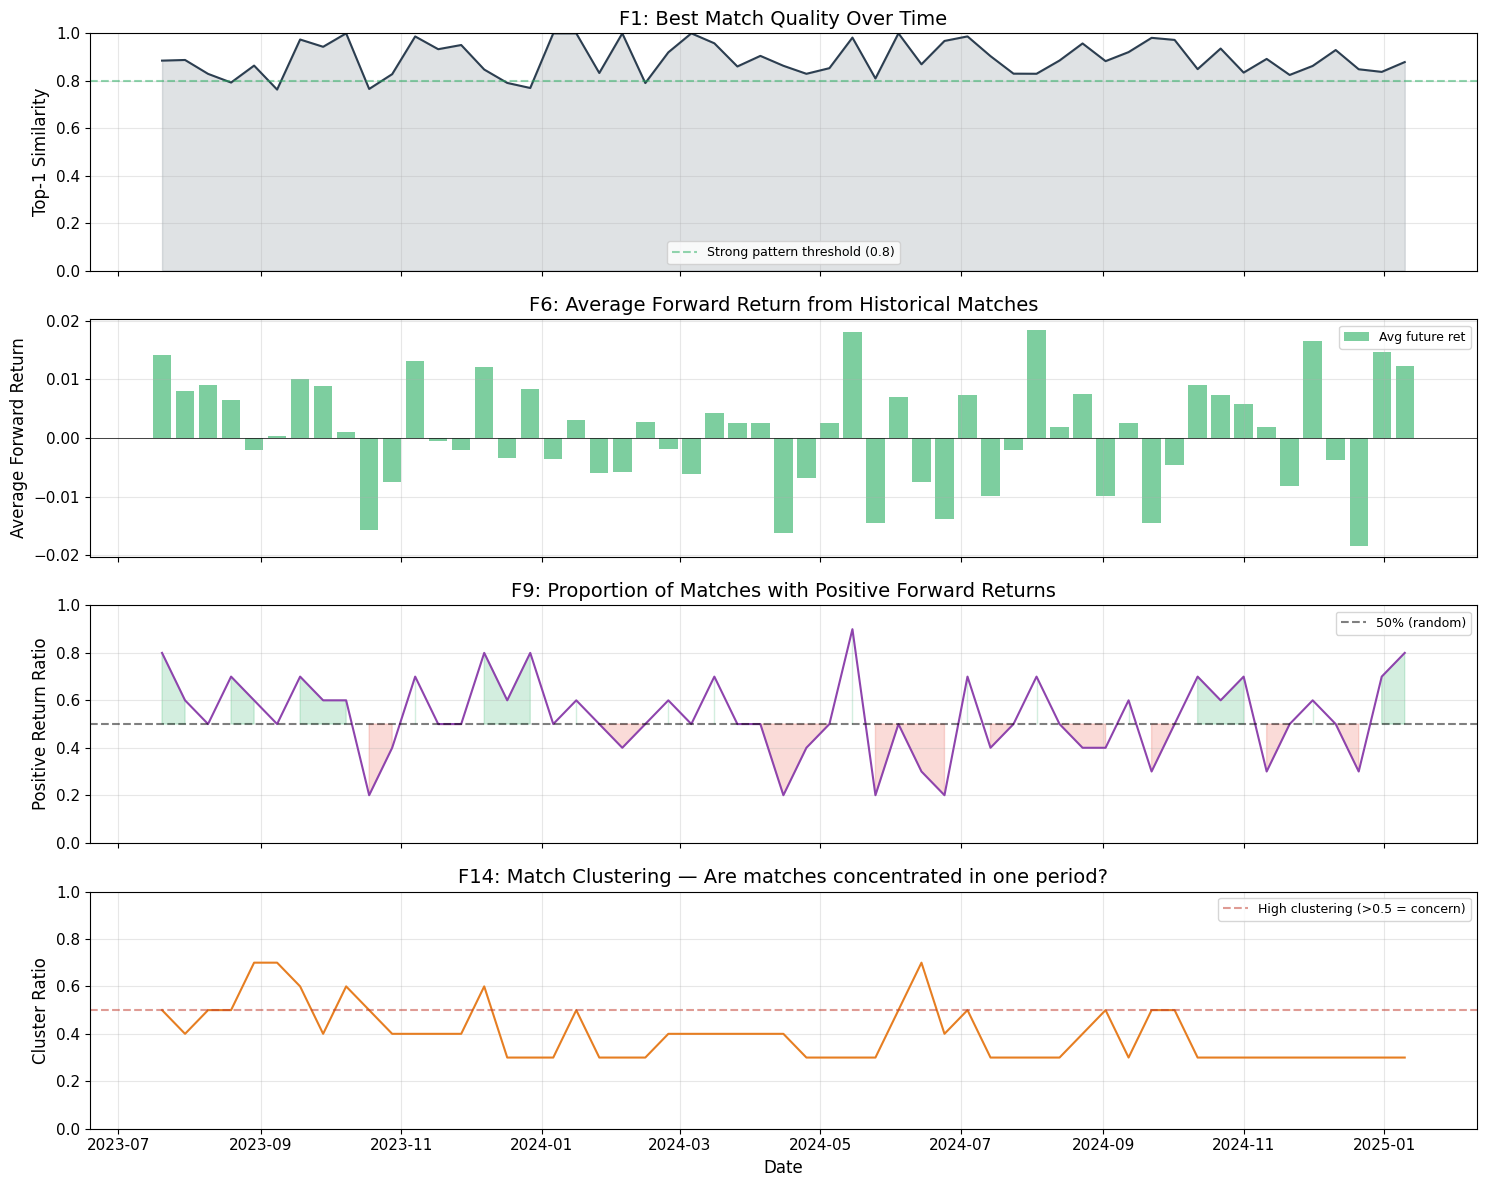

In [12]:
# Plot feature evolution
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# F1: Best match quality
axes[0].plot(valid_dates, top1_sim_series, linewidth=1.5, color="#2c3e50")
axes[0].fill_between(valid_dates, 0, top1_sim_series, alpha=0.15, color="#2c3e50")
axes[0].axhline(y=0.8, color="#27ae60", linestyle="--", alpha=0.5, label="Strong pattern threshold (0.8)")
axes[0].set_ylabel("Top-1 Similarity")
axes[0].set_title("F1: Best Match Quality Over Time")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# F6: Forward return signals
color_ret = "#e74c3c" if np.mean(avg_future_ret_series) < 0 else "#27ae60"
axes[1].bar(valid_dates, avg_future_ret_series, width=8, color=color_ret, alpha=0.6, label="Avg future ret")
axes[1].set_ylabel("Average Forward Return")
axes[1].set_title("F6: Average Forward Return from Historical Matches")
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# F9: Positive return ratio (proportion of matches that were bullish)
axes[2].plot(valid_dates, ret_consistency_series, linewidth=1.5, color="#8e44ad")
axes[2].fill_between(valid_dates, 0.5, ret_consistency_series,
                      where=np.array(ret_consistency_series) > 0.5, alpha=0.2, color="#27ae60")
axes[2].fill_between(valid_dates, ret_consistency_series, 0.5,
                      where=np.array(ret_consistency_series) <= 0.5, alpha=0.2, color="#e74c3c")
axes[2].axhline(y=0.5, color="black", linestyle="--", alpha=0.5, label="50% (random)")
axes[2].set_ylabel("Positive Return Ratio")
axes[2].set_title("F9: Proportion of Matches with Positive Forward Returns")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1)

# F14: Cluster ratio
axes[3].plot(valid_dates, cluster_ratio_series, linewidth=1.5, color="#e67e22")
axes[3].axhline(y=0.5, color="#c0392b", linestyle="--", alpha=0.5, label="High clustering (>0.5 = concern)")
axes[3].set_ylabel("Cluster Ratio")
axes[3].set_title("F14: Match Clustering — Are matches concentrated in one period?")
axes[3].set_xlabel("Date")
axes[3].legend(fontsize=9)
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('05_feature_evolution.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.close()
display(Image('05_feature_evolution.png'))

## 4. Performance Benchmark: Python vs C++

The pybind11/C++20 backend provides dramatic speedups for the most computationally intensive operations.

In [13]:
if CPP_AVAILABLE:
    print("=" * 60)
    print("PERFORMANCE BENCHMARK: Python vs C++ (pybind11/C++20)")
    print("=" * 60)

    # ⚠️ Absolute speedup numbers depend on hardware, OS, and compiler.
    # The relative ratio (Python/C++ time) is the stable metric.
    rng = np.random.default_rng(42)  # fixed seed for reproducibility

    # ── DTW single ──
    x = rng.standard_normal(19)  # L_query - 1
    y = rng.standard_normal(19)
    n_iter = 5000

    # Verify output equivalence before timing
    py_ref = dtw_distance(x, y, window=5)
    cpp_ref = etf_core.dtw_distance(x, y, 5)
    assert abs(py_ref - cpp_ref) < 1e-8, f"DTW mismatch: {py_ref} vs {cpp_ref}"
    print(f"\n  ✅ DTW output verified (py={py_ref:.8f}, cpp={cpp_ref:.8f})")

    t0 = time.perf_counter()
    for _ in range(n_iter):
        dtw_distance(x, y, window=5)
    py_dtw_time = (time.perf_counter() - t0) / n_iter * 1e6

    t0 = time.perf_counter()
    for _ in range(n_iter):
        etf_core.dtw_distance(x, y, 5)
    cpp_dtw_time = (time.perf_counter() - t0) / n_iter * 1e6

    print(f"\n  DTW (L=19, window=5):")
    print(f"    Python: {py_dtw_time:8.1f} µs/call")
    print(f"    C++:    {cpp_dtw_time:8.1f} µs/call")
    print(f"    Speedup: {py_dtw_time/cpp_dtw_time:5.1f}×")

    # ── DTW batch (100 candidates) ──
    candidates = rng.standard_normal(100, 19)
    n_iter_batch = 50

    py_batch_ref = dtw_distance_batch(x, candidates, window=5)
    cpp_batch_ref = etf_core.dtw_distance_batch(x, candidates, 5)
    assert np.allclose(py_batch_ref, cpp_batch_ref, atol=1e-8), "DTW batch mismatch"
    print(f"  ✅ DTW batch output verified")

    t0 = time.perf_counter()
    for _ in range(n_iter_batch):
        dtw_distance_batch(x, candidates, window=5)
    py_batch_time = (time.perf_counter() - t0) / n_iter_batch * 1e3

    t0 = time.perf_counter()
    for _ in range(n_iter_batch):
        etf_core.dtw_distance_batch(x, candidates, 5)
    cpp_batch_time = (time.perf_counter() - t0) / n_iter_batch * 1e3

    print(f"\n  DTW Batch (100 candidates, L=19):")
    print(f"    Python: {py_batch_time:8.2f} ms/call")
    print(f"    C++:    {cpp_batch_time:8.2f} ms/call")
    print(f"    Speedup: {py_batch_time/cpp_batch_time:5.1f}×")

    # ── Pattern match single ──
    # Use more iterations with a warm-up round for stable measurement
    n_iter_pm = 20

    # Warm-up
    _ = pattern_match_single(prices, 500)
    _ = etf_core.pattern_match_single(prices, 500)

    # Verify output equivalence
    py_pm_ref = pattern_match_single(prices, 500)
    cpp_pm_ref = etf_core.pattern_match_single(prices, 500)
    all_match = True
    for key in py_pm_ref:
        if abs(py_pm_ref[key] - cpp_pm_ref[key]) > 1e-6:
            all_match = False
            break
    if all_match:
        print(f"  ✅ pattern_match_single output verified (15/15 features match)")
    else:
        print(f"  ⚠️  pattern_match_single: minor floating-point differences detected")

    t0 = time.perf_counter()
    for _ in range(n_iter_pm):
        pattern_match_single(prices, 500)
    py_pm_time = (time.perf_counter() - t0) / n_iter_pm * 1e3

    t0 = time.perf_counter()
    for _ in range(n_iter_pm):
        etf_core.pattern_match_single(prices, 500)
    cpp_pm_time = (time.perf_counter() - t0) / n_iter_pm * 1e3

    print(f"\n  pattern_match_single (full pipeline):")
    print(f"    Python: {py_pm_time:8.2f} ms/call")
    print(f"    C++:    {cpp_pm_time:8.2f} ms/call")
    print(f"    Speedup: {py_pm_time/cpp_pm_time:5.1f}×")

    speedup_dtw = py_dtw_time / cpp_dtw_time
    speedup_batch = py_batch_time / cpp_batch_time
    speedup_pm = py_pm_time / cpp_pm_time

    # ── Summary charts (separate axes for different units) ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # DTW single (µs)
    bars1 = axes[0].bar(["Python", "C++"], [py_dtw_time, cpp_dtw_time],
                        color=["#3498db", "#e74c3c"], alpha=0.8)
    axes[0].set_ylabel("µs / call")
    axes[0].set_title(f"DTW (L=19)\n{speedup_dtw:.1f}× speedup")
    axes[0].grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars1, [py_dtw_time, cpp_dtw_time]):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.1f}",
                     ha="center", va="bottom", fontsize=10)

    # DTW batch (ms)
    bars2 = axes[1].bar(["Python", "C++"], [py_batch_time, cpp_batch_time],
                        color=["#3498db", "#e74c3c"], alpha=0.8)
    axes[1].set_ylabel("ms / 100 candidates")
    axes[1].set_title(f"DTW Batch (×100)\n{speedup_batch:.1f}× speedup")
    axes[1].grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars2, [py_batch_time, cpp_batch_time]):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.1f}",
                     ha="center", va="bottom", fontsize=10)

    # Pattern match (ms)
    bars3 = axes[2].bar(["Python", "C++"], [py_pm_time, cpp_pm_time],
                        color=["#3498db", "#e74c3c"], alpha=0.8)
    axes[2].set_ylabel("ms / call")
    axes[2].set_title(f"Pattern Match (full pipeline)\n{speedup_pm:.1f}× speedup")
    axes[2].grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars3, [py_pm_time, cpp_pm_time]):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.1f}",
                     ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig('08_benchmark.png', dpi=100, bbox_inches='tight', facecolor='white')
    plt.close()
    display(Image('08_benchmark.png'))

    print(f"\n  Speedup summary: DTW={speedup_dtw:.1f}× | Batch={speedup_batch:.1f}× | Full={speedup_pm:.1f}×")
    print(f"  (Measured on this machine; absolute values vary by hardware)")
    print(f"\n  ✅ All benchmarks complete")
else:
    print("⚠️  C++ module not available — skipping benchmarks.")
    print("   Build with: cmake -B build -DPython_EXECUTABLE=(Get-Command python).Source; cmake --build build --config Release")

⚠️  C++ module not available — skipping benchmarks.
   Build with: cmake -B build -DPython_EXECUTABLE=(Get-Command python).Source; cmake --build build --config Release


## 5. Practical Use Case: Signal Generation

Combine pattern match features into a simple trading signal. This demonstrates how the 15 features feed into a strategy.

In [14]:
def generate_pattern_signal(
    features: Dict[str, float],
    min_quality_matches: int = 2,
    consensus_threshold: float = 0.6,
    scale_factor: float = 20.0,      # scales daily-like return to signal magnitude
    cluster_floor: float = 0.05,       # minimum signal floor when cluster_ratio=1
    verbose: bool = False,
) -> float:
    """
    Convert 15-dimensional pattern features into a trading signal ∈ [-1, 1].

    Positive = bullish pattern (go long)
    Negative = bearish pattern (go short / exit)
    Near zero = no clear signal

    Gate structure (three explicit layers):
      Gate 1 (match quality):  n_matches_above_thresh >= min_quality_matches
      Gate 2 (outcome consensus): max(positive_ratio, 1-positive_ratio) >= consensus_threshold
      Gate 3 (position sizing):  magnitude × cluster_penalty → bounded signal

    This is a simplified example — production strategies would calibrate weights
    and run walk-forward cross-validation on real data.
    """
    if verbose:
        print(f"--- Gate checks ---")

    # ── Gate 1: Match quality ──
    # n_matches_above_thresh >= 2 already implies top1_sim > 0.8 (scores > 0.8
    # are counted, so >= 2 matches above 0.8 guarantees strong pattern quality)
    n_quality = features["n_matches_above_thresh"]
    if n_quality < min_quality_matches:
        if verbose:
            print(f"  G1 FAIL: n_matches_above_thresh={n_quality} < {min_quality_matches}")
        return 0.0
    if verbose:
        print(f"  G1 PASS: {n_quality} quality matches")

    # ── Gate 2: Outcome consensus (bidirectional) ──
    # Use true consistency: max(positive_ratio, 1-positive_ratio) ∈ [0.5, 1]
    # 0.5 = random, 1.0 = all matches agree on direction
    positive_ratio = features["ret_sign_consistency"]
    true_consistency = max(positive_ratio, 1.0 - positive_ratio)
    majority_direction = 1 if positive_ratio >= 0.5 else -1

    if true_consistency < consensus_threshold:
        if verbose:
            print(f"  G2 FAIL: consistency={true_consistency:.2f} < {consensus_threshold}")
        return 0.0
    if verbose:
        print(f"  G2 PASS: consistency={true_consistency:.2f} direction={'bull' if majority_direction > 0 else 'bear'}")

    # ── Gate 3: Position sizing ──
    weighted_ret = features["weighted_future_ret"]

    # Magnitude: scale the daily-like return to [-1, 1] range
    # scale_factor maps expected daily return (~0.05%) to a reasonable signal
    magnitude = min(abs(weighted_ret) * scale_factor, 1.0)

    # Cluster penalty: penalize matches concentrated in narrow time windows
    # (suggests overfitting to one specific market regime)
    # floor ensures signal doesn't vanish entirely when clustering is high
    cluster_ratio = features["match_cluster_ratio"]
    cluster_penalty = max(1.0 - cluster_ratio, cluster_floor)

    signal = majority_direction * magnitude * cluster_penalty

    if verbose:
        print(f"  G3: magnitude={magnitude:.3f} cluster_penalty={cluster_penalty:.3f} → signal={signal:.3f}")

    return float(np.clip(signal, -1.0, 1.0))


# Scan for signals across time
scan_T = list(range(200, 780, 5))
signals = []
signal_dates = []

for T in scan_T:
    feats = pattern_match_single(prices, T)
    if feats is not None:
        sig = generate_pattern_signal(feats)
        signals.append(sig)
        signal_dates.append(dates[T])
    else:
        signals.append(0.0)
        signal_dates.append(dates[T])

signals = np.array(signals)
signal_dates_arr = np.array(signal_dates)

# Count signal events
bullish = np.sum(signals > 0.1)
bearish = np.sum(signals < -0.1)
neutral = np.sum((signals >= -0.1) & (signals <= 0.1))

# Show one example with verbose gate diagnostics
print("Example gate trace (T_idx=500):")
_example_feats = pattern_match_single(prices, 500)
if _example_feats:
    _ = generate_pattern_signal(_example_feats, verbose=True)

print(f"\nSignal scan: {len(scan_T)} points")
print(f"  Bullish (>0.1):  {bullish:3d} ({bullish/len(scan_T):.0%})")
print(f"  Bearish (<-0.1): {bearish:3d} ({bearish/len(scan_T):.0%})")
print(f"  Neutral:         {neutral:3d} ({neutral/len(scan_T):.0%})")

Example gate trace (T_idx=500):
--- Gate checks ---
  G1 PASS: 3 quality matches
  G2 PASS: consistency=0.90 direction=bull
  G3: magnitude=0.383 cluster_penalty=0.700 → signal=0.268

Signal scan: 116 points
  Bullish (>0.1):    5 (4%)
  Bearish (<-0.1):   8 (7%)
  Neutral:         103 (89%)


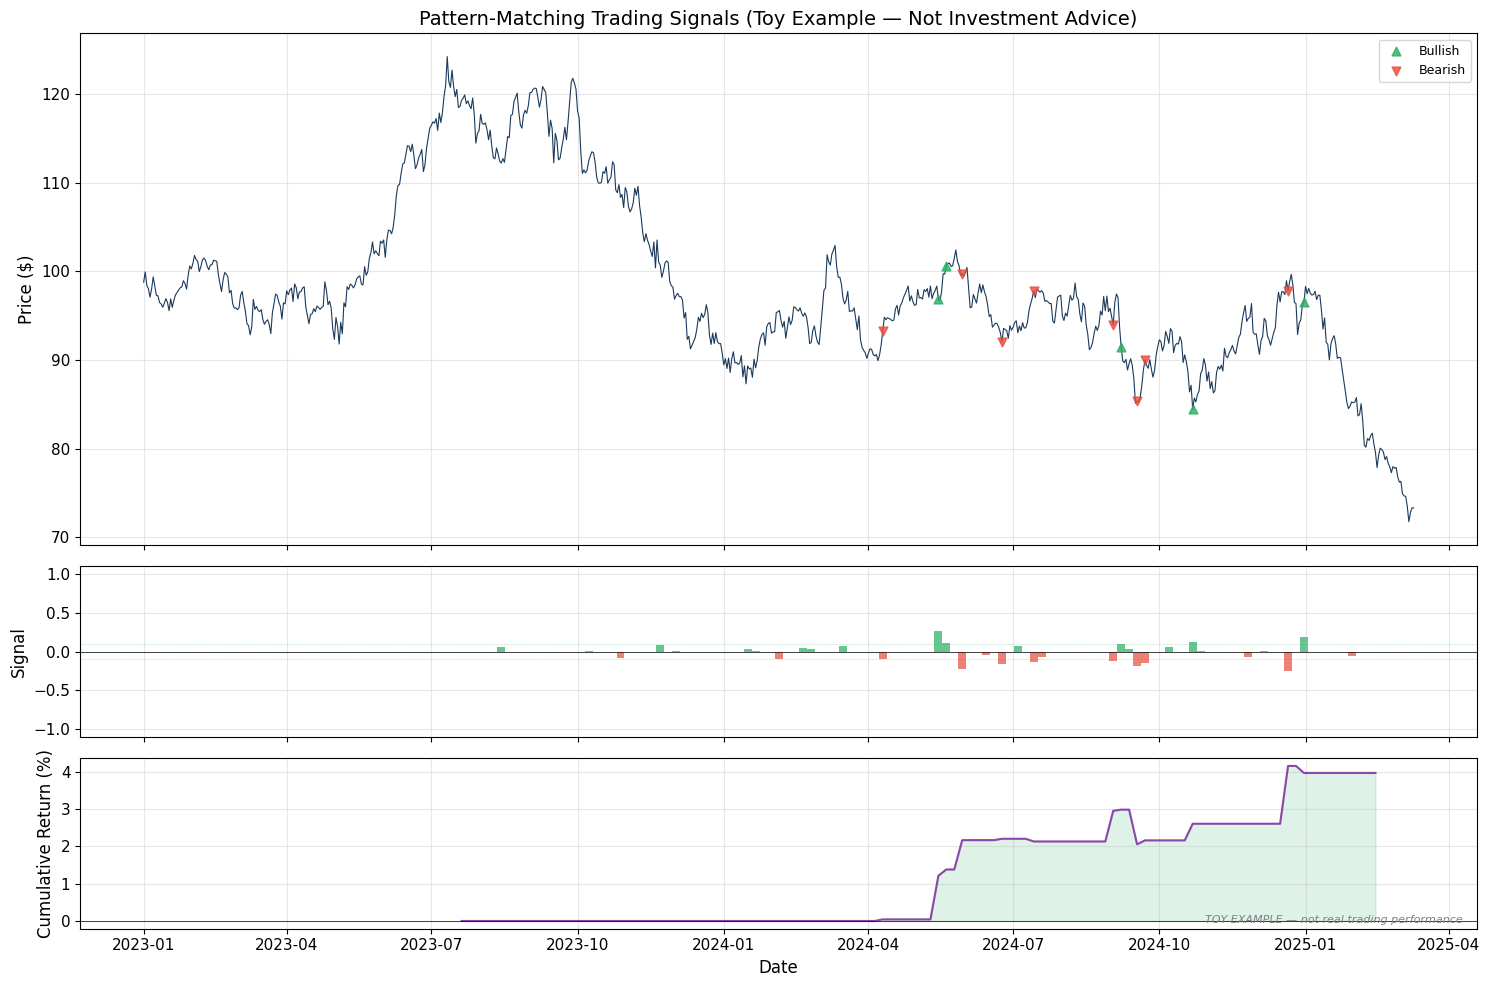

In [15]:
# ⚠️ TOY EXAMPLE — NOT INVESTMENT ADVICE ⚠️
# This simplified walk-forward illustration uses synthetic data and
# next-day execution assumptions. It does NOT reflect real trading
# (no transaction costs, no slippage, no same-bar constraints).
# Do NOT use this as a basis for actual investment decisions.
#
# Visualize signals on price chart
fig, axes = plt.subplots(3, 1, figsize=(15, 10), height_ratios=[3, 1, 1], sharex=True)

# Price
axes[0].plot(dates, prices, linewidth=0.8, color="#1a3a5c")
axes[0].set_ylabel("Price ($)")
axes[0].set_title("Pattern-Matching Trading Signals (Toy Example — Not Investment Advice)")
axes[0].grid(True, alpha=0.3)

# Mark signal points on price
bull_mask = signals > 0.1
bear_mask = signals < -0.1
if np.any(bull_mask):
    axes[0].scatter(signal_dates_arr[bull_mask], prices[scan_T][bull_mask],
                    color="#27ae60", s=40, marker="^", alpha=0.8, zorder=5, label="Bullish")
if np.any(bear_mask):
    axes[0].scatter(signal_dates_arr[bear_mask], prices[scan_T][bear_mask],
                    color="#e74c3c", s=40, marker="v", alpha=0.8, zorder=5, label="Bearish")
axes[0].legend(fontsize=9)

# Signal strength
axes[1].bar(signal_dates_arr, signals, width=5,
            color=["#27ae60" if s > 0 else "#e74c3c" if s < 0 else "#bdc3c7" for s in signals], alpha=0.7)
axes[1].axhline(y=0.1, color="#27ae60", linestyle="--", alpha=0.3, linewidth=0.5)
axes[1].axhline(y=-0.1, color="#e74c3c", linestyle="--", alpha=0.3, linewidth=0.5)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_ylabel("Signal")
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, alpha=0.3)

# Cumulative return from following signals
# (toy illustration: next-day execution, signal strength as position weight,
#  5-day holding period, geometrically compounded)
cumulative_pnl = [1.0]  # start at 1.0 for geometric compounding
for i, T in enumerate(scan_T):
    sig = signals[i]
    if T + 5 < len(prices) and abs(sig) > 0.1:
        # Next-day execution to avoid same-bar bias
        entry_price = prices[T + 1]
        exit_price = prices[min(T + 1 + 5, len(prices) - 1)]
        fut_ret = exit_price / entry_price - 1
        # Signal strength determines position size and direction
        pnl_contrib = sig * fut_ret
    else:
        pnl_contrib = 0.0
    cumulative_pnl.append(cumulative_pnl[-1] * (1.0 + pnl_contrib))
cumulative_pnl = np.array(cumulative_pnl[1:])

# Display as percentage return
cumulative_pct = (cumulative_pnl - 1.0) * 100
axes[2].plot(signal_dates_arr, cumulative_pct, linewidth=1.5, color="#8e44ad")
axes[2].fill_between(signal_dates_arr, 0, cumulative_pct,
                      where=cumulative_pct > 0, alpha=0.15, color="#27ae60")
axes[2].fill_between(signal_dates_arr, 0, cumulative_pct,
                      where=cumulative_pct <= 0, alpha=0.15, color="#e74c3c")
axes[2].axhline(y=0, color="black", linewidth=0.5)
axes[2].set_ylabel("Cumulative Return (%)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)
# Add disclaimer watermark
axes[2].text(0.99, 0.02, "TOY EXAMPLE — not real trading performance",
             transform=axes[2].transAxes, fontsize=8, color="gray",
             ha="right", va="bottom", style="italic")

plt.tight_layout()
plt.savefig('06_trading_signals.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.close()
display(Image('06_trading_signals.png'))

## 6. Batch DTW: Compare One Pattern Against Many

The `dtw_distance_batch` function computes DTW distances between one query and many candidates efficiently. This is useful for:

- Finding the most similar ETFs to a target
- Screening a universe of symbols for pattern similarity
- Pre-computing distance matrices for clustering

In [16]:
# Simulate: compare one query ETF to a universe of 50 candidate ETFs
n_etfs = 50
window_len = 19  # L_query - 1
rng = np.random.default_rng(123)

# Generate diverse ETF return patterns
query_etf = standardize_returns(prices[480:500])  # our query
candidate_etfs = np.empty((n_etfs, window_len))

# Mix of correlated and random patterns
for i in range(n_etfs):
    # Vary correlation to query
    noise_level = 0.3 + 0.7 * (i / n_etfs)  # increasing noise
    candidate_etfs[i] = (1 - noise_level) * query_etf + noise_level * rng.standard_normal(window_len)

# Batch DTW
t0 = time.perf_counter()
if CPP_AVAILABLE:
    top_idx, top_dists = etf_core.dtw_distance_batch(query_etf, candidate_etfs, 5, top_k=10)
    elapsed = (time.perf_counter() - t0) * 1e3
    engine = "C++ (etf_core)"
else:
    top_idx, top_dists = dtw_distance_batch(query_etf, candidate_etfs, window=5, top_k=10)
    elapsed = (time.perf_counter() - t0) * 1e3
    engine = "Python (NumPy)"

print(f"Batch DTW: 1 query × {n_etfs} candidates [{engine}]")
print(f"  Time: {elapsed:.2f} ms")
print(f"\n  Top-10 most similar ETFs:")
for rank, (idx, dist) in enumerate(zip(top_idx, top_dists)):
    marker = " ★" if rank == 0 else ""
    print(f"    {rank+1:2d}. ETF #{idx:2d}  dtw_distance={dist:.6f}{marker}")

Batch DTW: 1 query × 50 candidates [Python (NumPy)]
  Time: 8.72 ms

  Top-10 most similar ETFs:
     1. ETF # 4  dtw_distance=0.039296 ★
     2. ETF # 0  dtw_distance=0.040205
     3. ETF # 2  dtw_distance=0.042273
     4. ETF # 3  dtw_distance=0.051111
     5. ETF # 7  dtw_distance=0.053775
     6. ETF # 1  dtw_distance=0.055835
     7. ETF #15  dtw_distance=0.056500
     8. ETF # 6  dtw_distance=0.056634
     9. ETF # 8  dtw_distance=0.063712
    10. ETF # 9  dtw_distance=0.067473


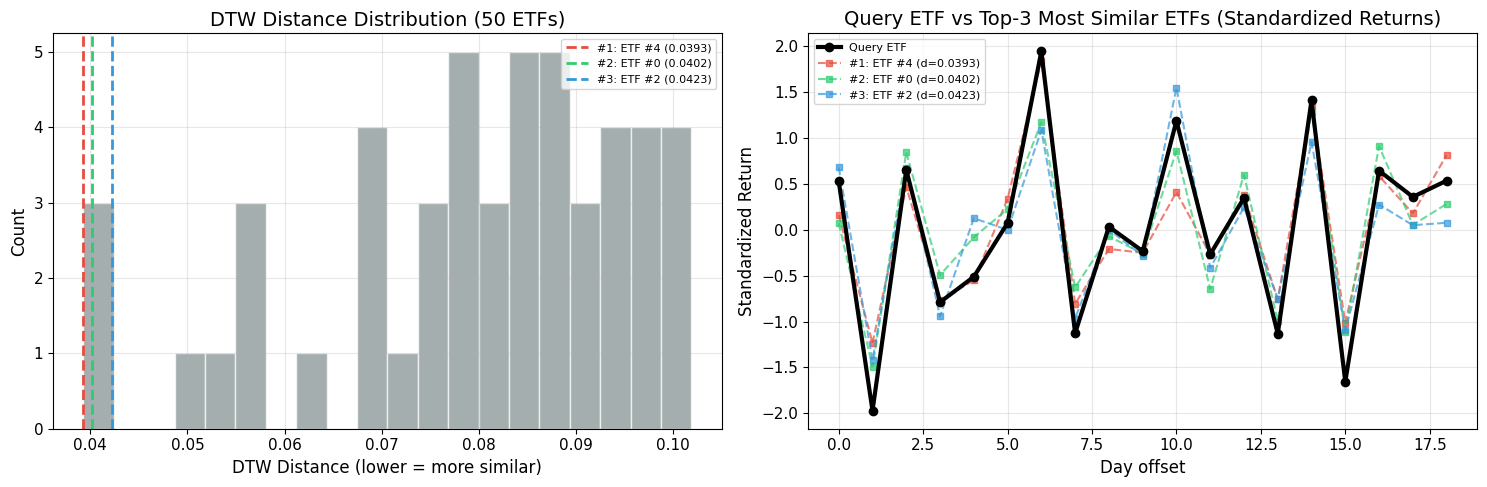

In [17]:
# Visualize: Query ETF vs Top-3 most similar ETFs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_top3 = ["#e74c3c", "#2ecc71", "#3498db"]

# Left: DTW distance distribution
all_dists = np.array([dtw_distance(query_etf, c, window=5) for c in candidate_etfs])
axes[0].hist(all_dists, bins=20, color="#7f8c8d", edgecolor="white", alpha=0.7)
for rank, (idx, dist) in enumerate(zip(top_idx[:3], top_dists[:3])):
    axes[0].axvline(x=dist, color=colors_top3[rank], linewidth=2, linestyle="--",
                    label=f"#{rank+1}: ETF #{idx} ({dist:.4f})")
axes[0].set_title(f"DTW Distance Distribution ({n_etfs} ETFs)")
axes[0].set_xlabel("DTW Distance (lower = more similar)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: Overlay query vs top-3
x_axis = np.arange(window_len)
axes[1].plot(x_axis, query_etf, "o-", linewidth=3, markersize=6, color="black", label="Query ETF", zorder=10)
for rank, (idx, dist) in enumerate(zip(top_idx[:3], top_dists[:3])):
    axes[1].plot(x_axis, candidate_etfs[idx], "s--", linewidth=1.5, markersize=4,
                 color=colors_top3[rank], alpha=0.7, label=f"#{rank+1}: ETF #{idx} (d={dist:.4f})")
axes[1].set_title("Query ETF vs Top-3 Most Similar ETFs (Standardized Returns)")
axes[1].set_xlabel("Day offset")
axes[1].set_ylabel("Standardized Return")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('07_batch_dtw.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.close()
display(Image('07_batch_dtw.png'))

## 7. API Reference Summary

| Function | Module | Description | C++ Accelerated |
|:---------|:-------|:------------|:---------------:|
| `standardize_returns(prices)` | `core.dtw` | (rets - mean) / std | ✅ |
| `cosine_similarity(x, y)` | `core.dtw` | cos(θ) ∈ [-1, 1] | ✅ |
| `dtw_distance(x, y, window)` | `core.dtw` | Sakoe-Chiba DTW | ✅ |
| `dtw_distance_batch(q, cands, w, top_k)` | `core.dtw` | 1-query × N-candidates | ✅ |
| `generate_query_candidates(prices, T, ...)` | `core.dtw` | Window generation | — |
| `pattern_match_single(prices, T_idx, ...)` | `core.pattern_match` | Full pipeline → 15 features | ✅ |
| `extract_morph_features(prices, T_idx, ...)` | `core.pattern_match` | Alias for above |  —  |
| `compute_adx(high, low, close, n)` | `core.technical` | ADX indicator | ✅ |
| `compute_atr(high, low, close, n)` | `core.technical` | ATR indicator | — |

---

## Next Steps

- **Replace synthetic data** with real ETF prices (e.g., `yfinance` or `akshare`)
- **Calibrate signal weights** using walk-forward cross-validation
- **Add risk management** (ATR-based position sizing from `compute_atr`)
- **Combine with ADX** trend filter (`compute_adx`)
- **Explore the C++ source** in `src/cpp/` for implementation details

---

> **Project**: [github.com/redamancy231-create/etf-pattern-match-pybind11](https://github.com/redamancy231-create/etf-pattern-match-pybind11)  
> **License**: MIT  
> **Built with**: Python 3.12 · NumPy · pybind11 3.0.4 · C++20 · MSVC 19.51